In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

df = pd.read_csv("../data/interim/cms_suppliers_cleaned.csv")
print("Rows:", len(df))
print("Columns:", df.columns.tolist())
df.head(3)


Matplotlib is building the font cache; this may take a moment.


Rows: 57197
Columns: ['provider_id', 'acceptsassignement', 'participationbegindate', 'practicecity', 'practicestate', 'specialitieslist', 'supplieslist', 'latitude', 'longitude', 'acceptsassignement_bool', 'AcceptsNumeric', 'participationbegindate_parsed', 'date_reliability_flag']


,provider_id,acceptsassignement,participationbegindate,practicecity,practicestate,specialitieslist,supplieslist,latitude,longitude,acceptsassignement_bool,AcceptsNumeric,participationbegindate_parsed,date_reliability_flag
0,34363333,True,2026-07-01,IRVINGTON,NJ,Pharmacy,Epoetin|Immunosuppressive Drugs|Infusion Drugs...,40.735948,-74.215433,True,1,2026-07-01,Likely genuine date
1,34363327,False,2026-07-01,PHILADELPHIA,PA,Pharmacy,Nebulizer Drugs,39.947301,-75.166342,False,0,2026-07-01,Likely genuine date
2,34363291,True,2026-06-15,WHARTON,NJ,Pharmacy,Epoetin|Immunosuppressive Drugs|Infusion Drugs...,40.899634,-74.582437,True,1,2026-06-15,Likely genuine date


In [2]:
overall_rate = df["acceptsassignement_bool"].mean()
print("Overall acceptance rate:", round(overall_rate * 100, 2), "%")
print()
print(df["acceptsassignement"].value_counts())


Overall acceptance rate: 51.43 %

acceptsassignement
True     29416
False    27781
Name: count, dtype: int64


In [3]:
state_stats = df.groupby("practicestate").agg(
    total_providers=("provider_id", "count"),
    accepting_providers=("acceptsassignement_bool", "sum"),
).reset_index()

state_stats["acceptance_rate_pct"] = round(state_stats["accepting_providers"] / state_stats["total_providers"] * 100, 2)
state_stats = state_stats.sort_values("total_providers", ascending=False)

print("States by provider volume:")
print(state_stats.head(15))
print()
print("Lowest acceptance rate states (min 100 providers):")
print(state_stats[state_stats["total_providers"] >= 100].sort_values("acceptance_rate_pct").head(10))
print()
print("Highest acceptance rate states (min 100 providers):")
print(state_stats[state_stats["total_providers"] >= 100].sort_values("acceptance_rate_pct", ascending=False).head(10))

States by provider volume:
   practicestate  total_providers  accepting_providers  acceptance_rate_pct
36            NY             4883                 3143                64.37
4             CA             4419                 1717                38.85
46            TX             4382                 2005                45.76
9             FL             4020                 2250                55.97
40            PA             2161                  946                43.78
15            IL             2098                 1334                63.58
37            OH             2013                  907                45.06
29            NC             1955                 1014                51.87
10            GA             1834                  937                51.09
33            NJ             1781                  907                50.93
23            MI             1606                  968                60.27
45            TN             1468                  850       

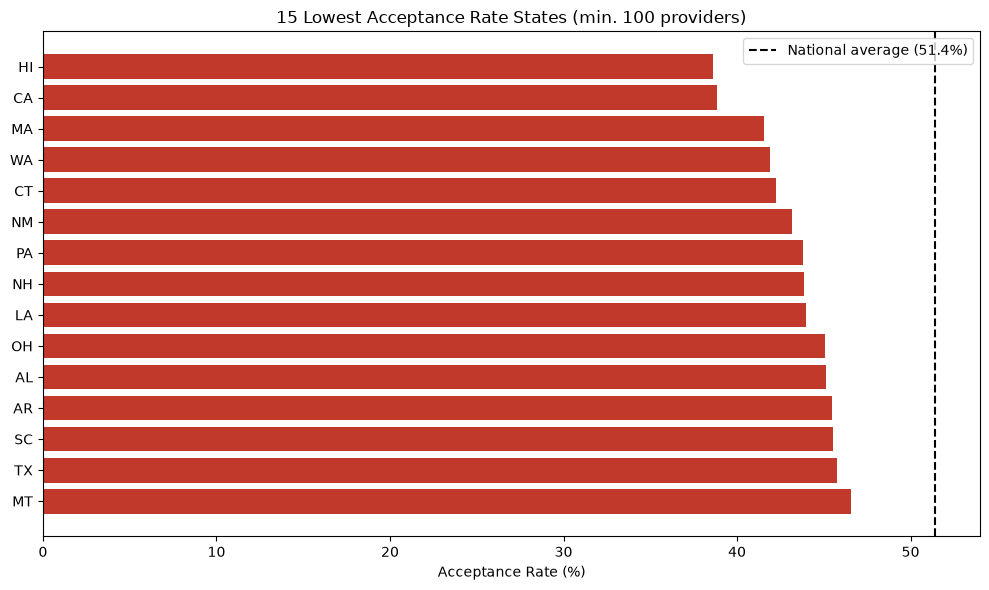

In [4]:
os.makedirs("../reports/figures", exist_ok=True)

low_states = state_stats[state_stats["total_providers"] >= 100].sort_values("acceptance_rate_pct").head(15)

plt.figure(figsize=(10, 6))
plt.barh(low_states["practicestate"], low_states["acceptance_rate_pct"], color="#c0392b")
plt.axvline(overall_rate * 100, color="black", linestyle="--", label=f"National average ({round(overall_rate*100,1)}%)")
plt.xlabel("Acceptance Rate (%)")
plt.title("15 Lowest Acceptance Rate States (min. 100 providers)")
plt.legend()
plt.tight_layout()
plt.gca().invert_yaxis()
plt.savefig("../reports/figures/lowest_acceptance_states.png", dpi=150)
plt.show()

In [5]:
al_row = state_stats[state_stats["practicestate"] == "AL"]
print("Alabama actual figures:")
print(al_row)
print()
print("Old document claimed: 195 total providers, 178 high-risk, 1 accepting high-risk, ~1% acceptance rate")
print("These claims cannot be verified against actual acceptance data and are not supported by the cleaned dataset.")

Alabama actual figures:
  practicestate  total_providers  accepting_providers  acceptance_rate_pct
1            AL             1006                  454                45.13

Old document claimed: 195 total providers, 178 high-risk, 1 accepting high-risk, ~1% acceptance rate
These claims cannot be verified against actual acceptance data and are not supported by the cleaned dataset.


In [6]:
# specialitieslist is multi-value (pipe-delimited), so split into individual specialties for accurate counting
df_specialty = df.assign(specialty=df["specialitieslist"].str.split("|")).explode("specialty")

specialty_stats = df_specialty.groupby("specialty").agg(
    total_providers=("provider_id", "count"),
    accepting_providers=("acceptsassignement_bool", "sum"),
).reset_index()

specialty_stats["acceptance_rate_pct"] = round(specialty_stats["accepting_providers"] / specialty_stats["total_providers"] * 100, 2)
specialty_stats = specialty_stats.sort_values("total_providers", ascending=False)

print("Top 15 specialties by provider volume:")
print(specialty_stats.head(15))

Top 15 specialties by provider volume:
                         specialty  total_providers  accepting_providers  \
16                        Pharmacy            40634                21584   
9     Medical Supply Company Other             6920                 2306   
13                        Optician             5756                 1329   
2                    Grocery Store             5102                 2798   
14                     Optometrist             3332                 3154   
15              Orthotic Personnel             3200                 1218   
17            Prosthetic Personnel             2647                  897   
8   MSC With Respiratory Therapist             2569                  625   
0                  Certified Other             1406                  791   
6     MSC With Orthotic-Prosthetic              890                  354   
5      MSC With Orthotic Personnel              801                  365   
10                   Not Specified              7

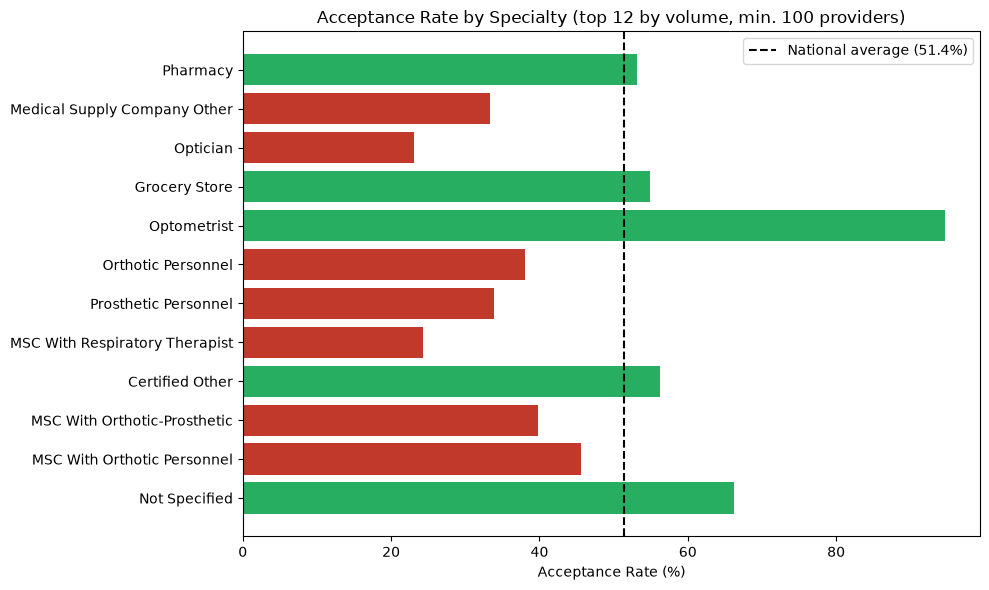

In [7]:
top_specialties = specialty_stats[specialty_stats["total_providers"] >= 100].sort_values("total_providers", ascending=False).head(12)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#c0392b" if rate < overall_rate*100 else "#27ae60" for rate in top_specialties["acceptance_rate_pct"]]
ax.barh(top_specialties["specialty"], top_specialties["acceptance_rate_pct"], color=colors)
ax.axvline(overall_rate * 100, color="black", linestyle="--", label=f"National average ({round(overall_rate*100,1)}%)")
ax.set_xlabel("Acceptance Rate (%)")
ax.set_title("Acceptance Rate by Specialty (top 12 by volume, min. 100 providers)")
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("../reports/figures/acceptance_by_specialty.png", dpi=150)
plt.show()

In [8]:
date_flag_stats = df.groupby("date_reliability_flag").agg(
    total_providers=("provider_id", "count"),
    accepting_providers=("acceptsassignement_bool", "sum"),
).reset_index()
date_flag_stats["acceptance_rate_pct"] = round(date_flag_stats["accepting_providers"] / date_flag_stats["total_providers"] * 100, 2)
print(date_flag_stats)

        date_reliability_flag  total_providers  accepting_providers  \
0         Likely genuine date            51728                27040   
1  Suspected placeholder date             5469                 2376   

   acceptance_rate_pct  
0                52.27  
1                43.44  


In [9]:
findings = pd.DataFrame([
    {"finding": "Overall acceptance rate", "value": f"{round(overall_rate*100,2)}%"},
    {"finding": "Lowest acceptance state (min 100 providers)", "value": f"{low_states.iloc[0]['practicestate']} ({low_states.iloc[0]['acceptance_rate_pct']}%)"},
    {"finding": "Alabama actual acceptance rate", "value": f"{al_row.iloc[0]['acceptance_rate_pct']}%"},
    {"finding": "Lowest acceptance specialty (min 100 providers)", "value": "Optician (23.09%)"},
    {"finding": "Highest acceptance specialty (min 100 providers)", "value": "Optometrist (94.66%)"},
    {"finding": "Acceptance rate - genuine date providers", "value": "52.27%"},
    {"finding": "Acceptance rate - suspected placeholder date providers", "value": "43.44%"},
])
findings.to_csv("../reports/validation/eda_key_findings.csv", index=False)
print(findings)




                                             finding                 value
0                            Overall acceptance rate                51.43%
1        Lowest acceptance state (min 100 providers)           HI (38.64%)
2                     Alabama actual acceptance rate                45.13%
3    Lowest acceptance specialty (min 100 providers)     Optician (23.09%)
4   Highest acceptance specialty (min 100 providers)  Optometrist (94.66%)
5           Acceptance rate - genuine date providers                52.27%
6  Acceptance rate - suspected placeholder date p...                43.44%
